**Import Libraries**

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

**Read csv file**

In [22]:
df = pd.read_csv('/content/patient.csv')
print(f"Original dataset shape: {df.shape}")
print(f"Original rows: {len(df)}")
df.head()

Original dataset shape: (4212, 14)
Original rows: 4212


,id,sex,birth_year,country,region,group,infection_reason,infection_order,infected_by,contact_number,confirmed_date,released_date,deceased_date,state
0,1,female,1984.0,China,filtered at airport,NaN,visit to Wuhan,1.0,NaN,45.0,2020-01-20,2020-02-06,NaN,released
1,2,male,1964.0,Korea,filtered at airport,NaN,visit to Wuhan,1.0,NaN,75.0,2020-01-24,2020-02-05,NaN,released
2,3,male,1966.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,16.0,2020-01-26,2020-02-12,NaN,released
3,4,male,1964.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,95.0,2020-01-27,2020-02-09,NaN,released
4,5,male,1987.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,31.0,2020-01-30,NaN,NaN,isolated


**Clean and format the data**

In [39]:


# Step 2: CLEAN the date columns
df['confirmed_date'] = pd.to_datetime(df['confirmed_date'], errors='coerce')
df['released_date'] = pd.to_datetime(df['released_date'], errors='coerce')
df['deceased_date'] = pd.to_datetime(df['deceased_date'], errors='coerce')

# Step 3: Keep only rows with valid confirmed dates
before = len(df)
df = df[df['confirmed_date'].notna()].copy()
print(f"Removed {before - len(df)} rows with missing confirmed_date")

# Step 4: Fill missing values APPROPRIATELY
df['sex'] = df['sex'].fillna('Unknown')
df['region'] = df['region'].fillna('Unknown')
df['group'] = df['group'].fillna('None')
df['infection_reason'] = df['infection_reason'].fillna('Unknown')
df['infection_order'] = df['infection_order'].fillna(0)
df['contact_number'] = df['contact_number'].fillna(0)

# Step 5: Remove rows with invalid deceased dates
before = len(df)
df = df[df['deceased_date'].isna() | (df['deceased_date'] >= df['confirmed_date'])]
print(f"Removed {before - len(df)} rows with invalid deceased dates")

# Step 6: Calculate age ONLY for rows with birth_year
df['birth_year'] = pd.to_numeric(df['birth_year'], errors='coerce')
df['age'] = df['confirmed_date'].dt.year - df['birth_year']
df.loc[(df['age'] <= 0) | (df['age'] >= 120), 'age'] = np.nan

# DATA QUALITY
print("\n" + "="*60)
print("DATA QUALITY ")
print("="*60)
print(f"Total records: {len(df)}")
print(f"Records with age data: {df['age'].notna().sum()} ({df['age'].notna().sum()/len(df)*100:.1f}%)")
print(f"Records with sex data: {df['sex'].notna().sum()} ({df['sex'].notna().sum()/len(df)*100:.1f}%)")
print(f"Records with contact_number: {df['contact_number'].notna().sum()} ({df['contact_number'].notna().sum()/len(df)*100:.1f}%)")


print(f"\nFINAL DATASET: {len(df)} valid cases")

Removed 0 rows with missing confirmed_date
Removed 0 rows with invalid deceased dates

DATA QUALITY 
Total records: 4208
Records with age data: 288 (6.8%)
Records with sex data: 4208 (100.0%)
Records with contact_number: 4208 (100.0%)

FINAL DATASET: 4208 valid cases


**Recovery days calculation**

In [24]:
# Calculate recovery days
df['recovery_days'] = (df['released_date'] - df['confirmed_date']).dt.days
df['recovery_days'] = df['recovery_days'].clip(lower=0)

# Create a separate dataframe for recovered patients with valid data
recovered = df[(df['state'] == 'released') & (df['recovery_days'] > 0)].copy()

print(f"Total recovered patients: {len(recovered)}")
print(f"Recovered patients with age data: {recovered['age'].notna().sum()}")
print(f"Recovered patients with contact data: {recovered['contact_number'].notna().sum()}")

Total recovered patients: 28
Recovered patients with age data: 28
Recovered patients with contact data: 28


**Age calculation**

In [25]:
# Calculate age - show real data quality
print("\n" + "="*50)
print("AGE DATA QUALITY CHECK")
print("="*50)

# Only show stats for rows with actual age data
age_available = df[df['age'].notna()].copy()

if len(age_available) > 0:
    print(f"Age available for: {len(age_available)} out of {len(df)} rows ({len(age_available)/len(df)*100:.1f}%)")
    print(f"Age range: {age_available['age'].min():.0f} to {age_available['age'].max():.0f} years")
    print(f"Mean age: {age_available['age'].mean():.1f} years")
    print(f"Median age: {age_available['age'].median():.1f} years")

else:
    print("No age data available - skipping age analysis")

# Show sample of rows with age data
df[['birth_year', 'age']].head(10)


AGE DATA QUALITY CHECK
Age available for: 288 out of 4208 rows (6.8%)
Age range: 2 to 83 years
Mean age: 46.7 years
Median age: 48.0 years


,birth_year,age
0,1984.0,36.0
1,1964.0,56.0
2,1966.0,54.0
3,1964.0,56.0
4,1987.0,33.0
5,1964.0,56.0
6,1991.0,29.0
7,1957.0,63.0
8,1992.0,28.0
9,1966.0,54.0


**Infection by Gender-wise**

Gender analysis based on 314 records (7.5% of total)


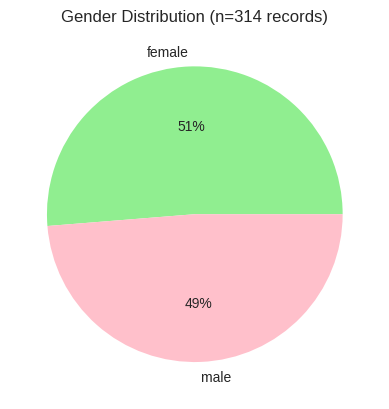

In [26]:
gender_data = df[df['sex'] != 'Unknown'].copy()

if len(gender_data) > 0:
    print(f"Gender analysis based on {len(gender_data)} records ({len(gender_data)/len(df)*100:.1f}% of total)")
    gender_data['sex'].value_counts().plot(kind='pie', autopct='%1.0f%%', colors=['lightgreen', 'pink'])
    plt.title(f'Gender Distribution (n={len(gender_data)} records)')
    plt.ylabel('')
    plt.show()

else:
    print("Insufficient gender data for analysis")

**Infection by Age-wise**


Age analysis based on 288 patients (6.8% of total)


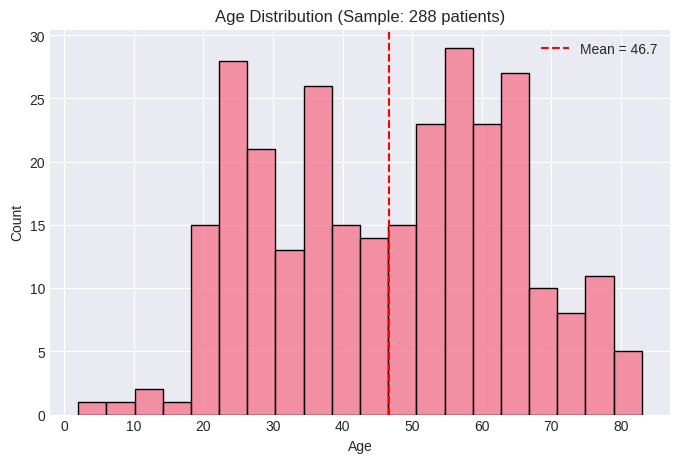

Mean Age: 46.7


In [27]:

age_available = df[df['age'].notna()].copy()

if len(age_available) > 5:
    print(f"\nAge analysis based on {len(age_available)} patients ({len(age_available)/len(df)*100:.1f}% of total)")


    mean_age = age_available['age'].mean()

    plt.figure(figsize=(8,5))
    sns.histplot(age_available['age'], bins=20)
    plt.axvline(mean_age, color='red', linestyle='--', label=f'Mean = {mean_age:.1f}')
    plt.title(f"Age Distribution (Sample: {len(age_available)} patients)")
    plt.xlabel("Age")
    plt.legend()
    plt.show()

    print(f"Mean Age: {mean_age:.1f}")

else:
    print("Insufficient age data for analysis")

**Infection by region-wise**

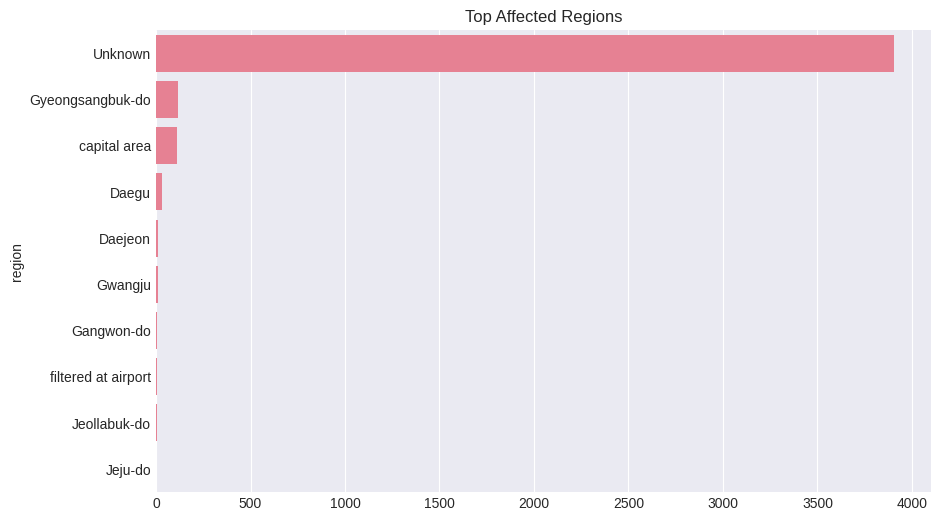

In [28]:
top_regions = df['region'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_regions.values,
    y=top_regions.index
)

plt.title("Top Affected Regions")

plt.show()

**Primary reasons for Spreading**

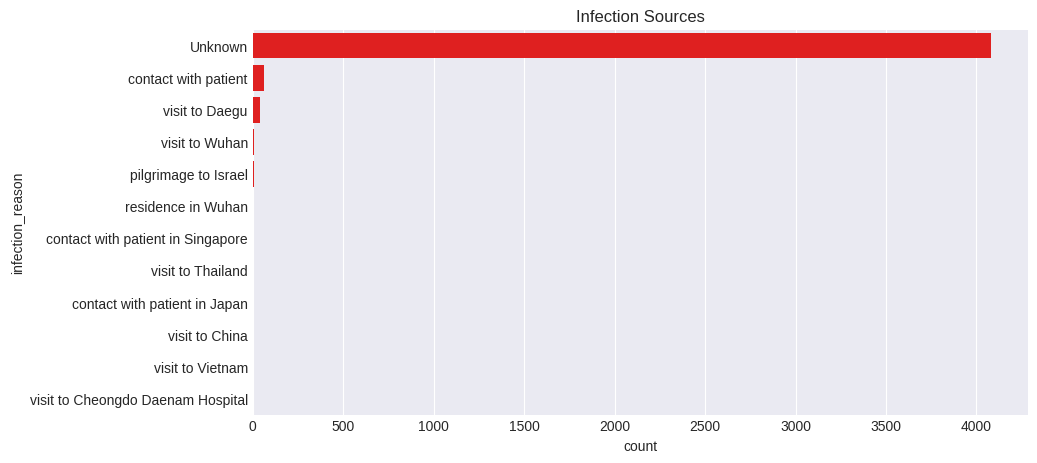

In [29]:
plt.figure(figsize=(10,5))

sns.countplot(
    y='infection_reason',
    data=df,
    order=df['infection_reason'].value_counts().index,
    color='red'
)

plt.title("Infection Sources")

plt.show()

**Order of infection**

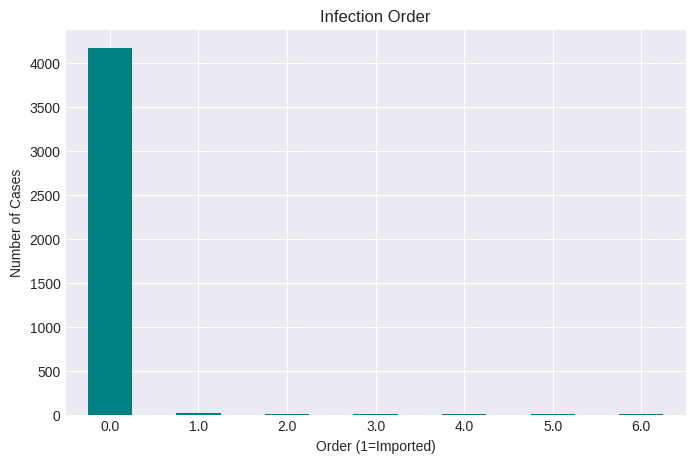

In [30]:
plt.figure(figsize=(8,5))
df['infection_order'].value_counts().sort_index().plot(kind='bar', color='teal')
plt.title('Infection Order')
plt.xlabel('Order (1=Imported)')
plt.ylabel('Number of Cases')
plt.xticks(rotation=0)
plt.show()


**Contact Exposure levels**

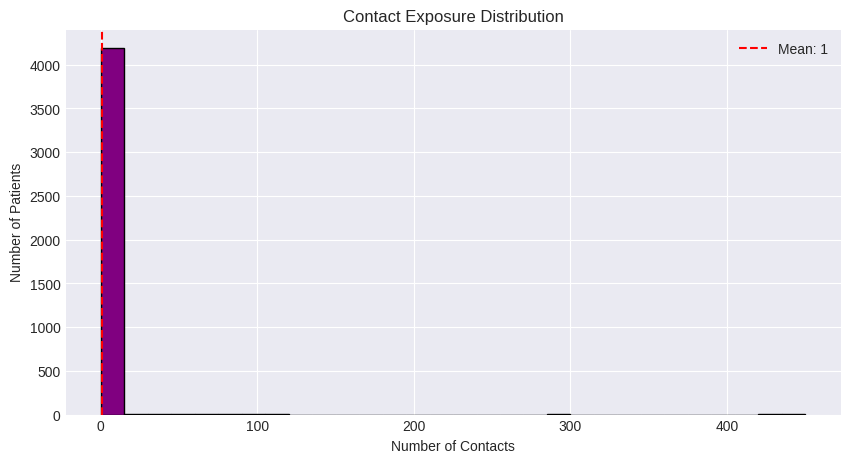

In [31]:
plt.figure(figsize=(10, 5))
df[df['contact_number'] < 500]['contact_number'].hist(bins=30, color='purple', edgecolor='black')
plt.axvline(df['contact_number'].mean(), color='red', linestyle='--',
            label=f'Mean: {df["contact_number"].mean():.0f}')
plt.xlabel('Number of Contacts')
plt.ylabel('Number of Patients')
plt.title('Contact Exposure Distribution')
plt.legend()
plt.show()

**Recovery trends**

Average Recovery: 15.1 days
Median Recovery: 16.0 days
75% recover within: 19 days


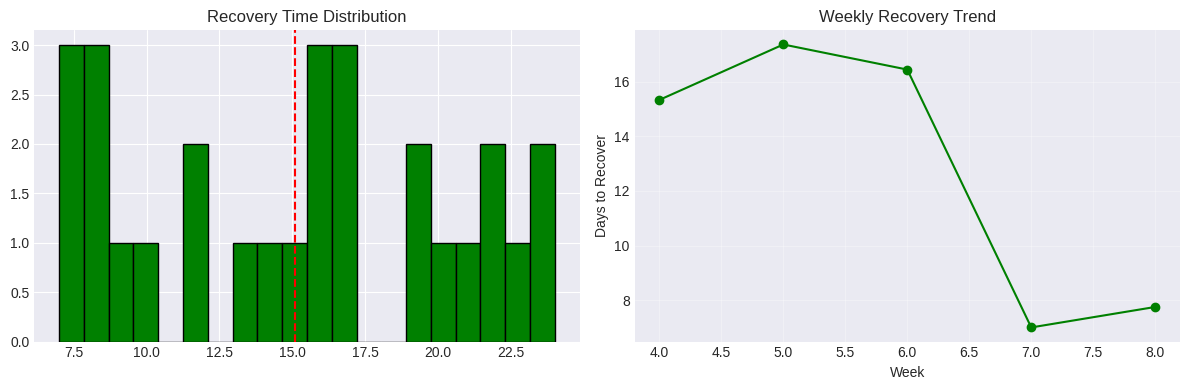

In [40]:
# Simple recovery trend analysis
df['recovery_time'] = (pd.to_datetime(df['released_date']) -
                       pd.to_datetime(df['confirmed_date'])).dt.days


recovered = df[(df['state'] == 'released') & (df['recovery_time'] > 0) & (df['recovery_time'] < 100)].copy()

# Basic stats
print(f"Average Recovery: {recovered['recovery_time'].mean():.1f} days")
print(f"Median Recovery: {recovered['recovery_time'].median():.1f} days")
print(f"75% recover within: {recovered['recovery_time'].quantile(0.75):.0f} days")

# Weekly trend - now this will work without warning
recovered['week'] = recovered['confirmed_date'].dt.isocalendar().week
weekly_trend = recovered.groupby('week')['recovery_time'].mean()

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(recovered['recovery_time'], bins=20, color='green', edgecolor='black')
plt.axvline(recovered['recovery_time'].mean(), color='red', linestyle='--')
plt.title('Recovery Time Distribution')

plt.subplot(1,2,2)
plt.plot(weekly_trend.index, weekly_trend.values, 'o-', color='green')
plt.title('Weekly Recovery Trend')
plt.xlabel('Week')
plt.ylabel('Days to Recover')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**confirmed and released cases across regions**

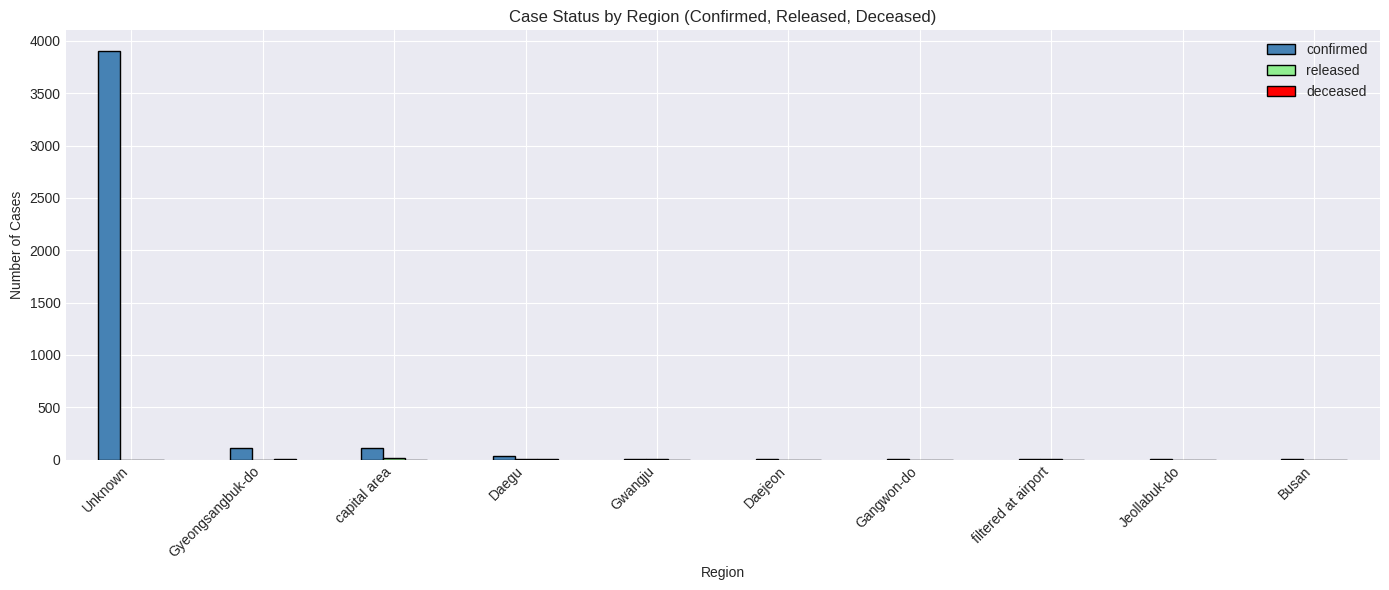

In [33]:
region_all = df.groupby('region').agg(
    confirmed=('id', 'count'),
    released=('state', lambda x: (x == 'released').sum()),
    deceased=('state', lambda x: (x == 'deceased').sum())
).sort_values('confirmed', ascending=False).head(10)

region_all[['confirmed', 'released', 'deceased']].plot(kind='bar', figsize=(14, 6),
                                                         color=['steelblue', 'lightgreen', 'red'],
                                                         edgecolor='black')
plt.xlabel('Region')
plt.ylabel('Number of Cases')
plt.title('Case Status by Region (Confirmed, Released, Deceased)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

**factors influencing recovery time**

RECOVERY ANALYSIS - DATA LIMITATIONS
Total recovered patients: 28
Recovered with age data: 28 (100.0%)


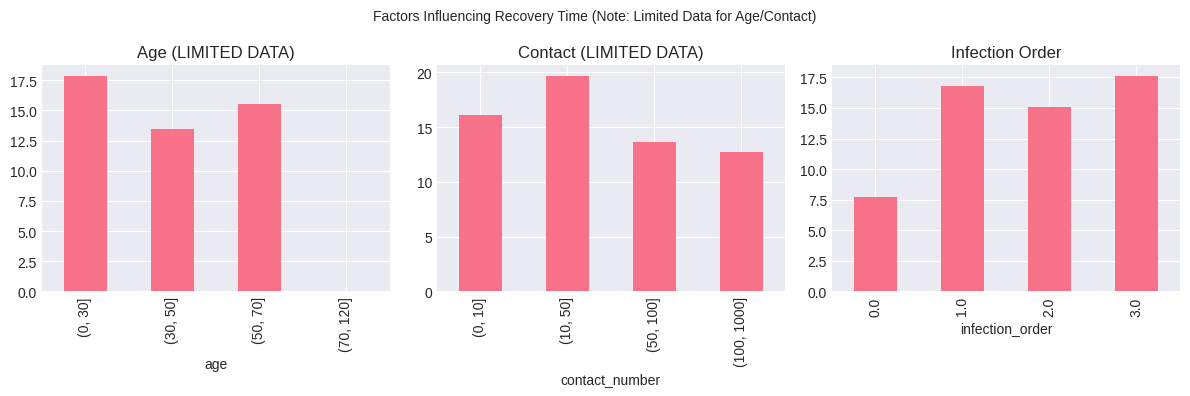

In [34]:
recovered = df[(df['state'] == 'released') & (df['recovery_days'] > 0)].copy()
recovered_with_age = recovered[recovered['age'].notna()].copy()

print("="*50)
print("RECOVERY ANALYSIS - DATA LIMITATIONS")
print("="*50)
print(f"Total recovered patients: {len(recovered)}")
print(f"Recovered with age data: {len(recovered_with_age)} ({len(recovered_with_age)/len(recovered)*100:.1f}%)")


if len(recovered_with_age) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # Age analysis - only if enough data
    if len(recovered_with_age) > 5:
        recovered_with_age.groupby(pd.cut(recovered_with_age['age'], bins=[0,30,50,70,120]), observed=False)['recovery_days'].mean().plot(kind='bar', ax=axes[0], title='Age (LIMITED DATA)')
    else:
        axes[0].text(0.5, 0.5, 'Insufficient age data', ha='center', transform=axes[0].transAxes)
        axes[0].set_title('Age - Insufficient Data')

    # Contact analysis - only if enough data
    recovered_with_contacts = recovered[recovered['contact_number'] > 0].copy()
    if len(recovered_with_contacts) > 5:
        recovered_with_contacts.groupby(pd.cut(recovered_with_contacts['contact_number'], bins=[0,10,50,100,1000]), observed=False)['recovery_days'].mean().plot(kind='bar', ax=axes[1], title='Contact (LIMITED DATA)')
    else:
        axes[1].text(0.5, 0.5, 'Insufficient contact data', ha='center', transform=axes[1].transAxes)
        axes[1].set_title('Contact - Insufficient Data')

    # Infection order - this has more data
    recovered.groupby('infection_order')['recovery_days'].mean().plot(kind='bar', ax=axes[2], title='Infection Order')

    plt.suptitle("Factors Influencing Recovery Time (Note: Limited Data for Age/Contact)", fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient data for recovery analysis")

**Recovery time**

Mean: 15.1 days
Median: 16.0 days


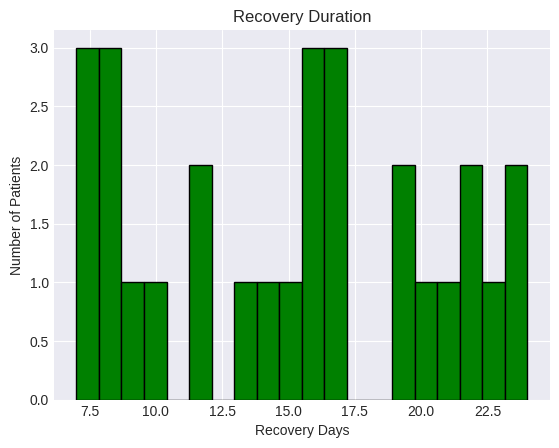

In [35]:
df['confirmed_date'] = pd.to_datetime(df['confirmed_date'])
df['released_date'] = pd.to_datetime(df['released_date'])
df['recovery_days'] = (df['released_date'] - df['confirmed_date']).dt.days

recovered = df[df['state'] == 'released']

print(f"Mean: {recovered['recovery_days'].mean():.1f} days")
print(f"Median: {recovered['recovery_days'].median():.1f} days")

plt.hist(recovered['recovery_days'].dropna(), bins=20, color='green', edgecolor='black')
plt.xlabel('Recovery Days')
plt.ylabel('Number of Patients')
plt.title('Recovery Duration')
plt.show()

**Correlation Heatmap**

Age data available: 288 rows
Contact data available: 4208 rows


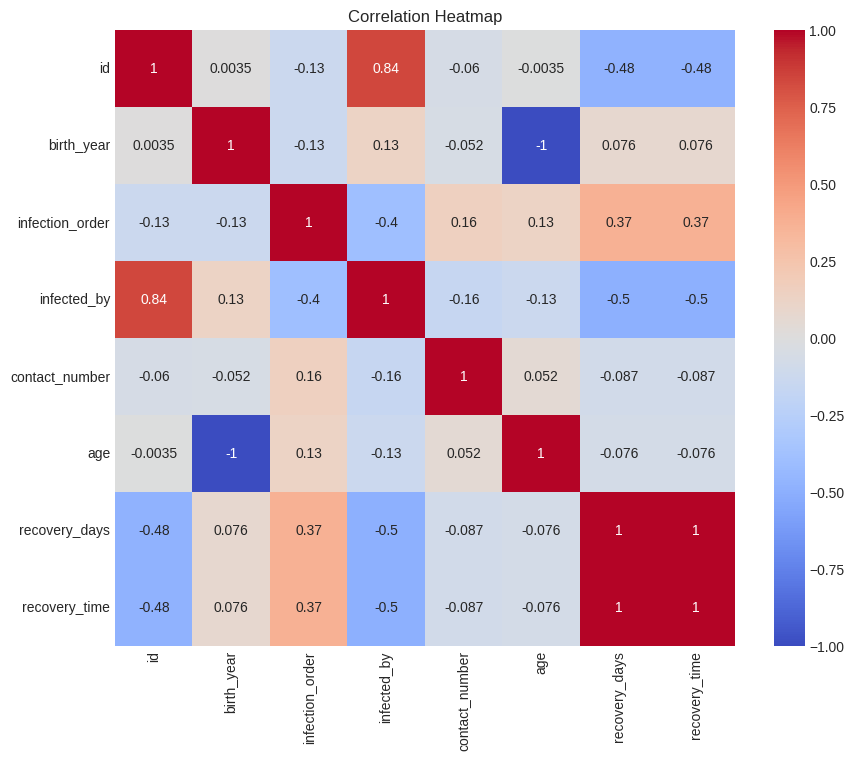

In [41]:

numeric_df = df.select_dtypes(include=np.number)



print(f"Age data available: {df['age'].notna().sum()} rows")
print(f"Contact data available: {df['contact_number'].notna().sum()} rows")


correlation = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()




**Regression model**

R² Score: -0.284
MAE: 5.1 days
Effect: +3.1 days per infection order



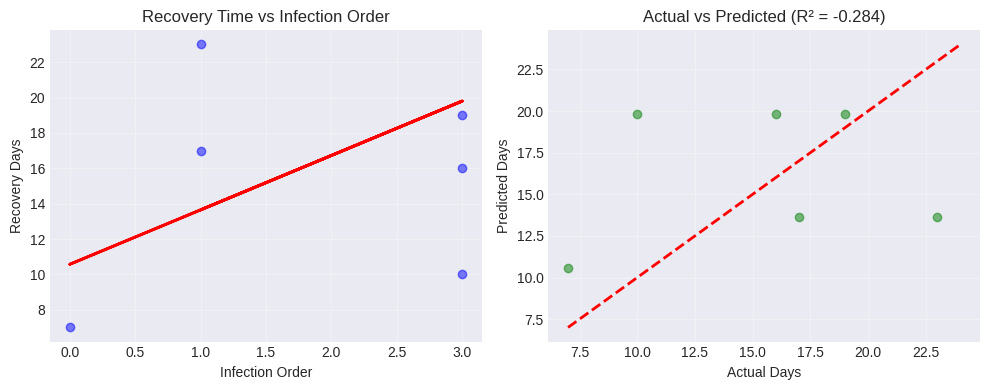

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
recovered = df[df['state'] == 'released'].copy()
recovered = recovered[recovered['recovery_days'].notna()]

X = recovered[['infection_order']]
y = recovered['recovery_days']

# Split and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Print results
print(f"R² Score: {r2_score(y_test, y_pred):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.1f} days")
print(f"Effect: +{model.coef_[0]:.1f} days per infection order\n")

# PLOT 1: Regression Line
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(X_test, y_test, alpha=0.5, color='blue')
plt.plot(X_test, y_pred, color='red', linewidth=2)
plt.xlabel('Infection Order')
plt.ylabel('Recovery Days')
plt.title('Recovery Time vs Infection Order')
plt.grid(True, alpha=0.3)

# PLOT 2: Actual vs Predicted
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
plt.xlabel('Actual Days')
plt.ylabel('Predicted Days')
plt.title(f'Actual vs Predicted (R² = {r2_score(y_test, y_pred):.3f})')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()